#  The Curse of Dimensionality
## A Beginner's Walkthrough with Python

> **What you'll learn:**  
> - What a "dimension" really means in machine learning  
> - Why adding more features can *hurt* your model  
> - How to visualize the curse using a simple house dataset  
> - Two practical fixes: Feature Selection & PCA  

**No prior ML experience needed.** We build everything from scratch with 10 houses.

---


##  Step 1 — Import Libraries

We only need three standard libraries for this entire notebook.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


##  Step 2 — Build Our House Dataset

We'll work with **10 simple houses**, each described by 3 features:



> **Why only 10 houses?**  
> A tiny dataset makes the curse *painfully obvious*. In real projects you might have thousands of rows — but the math works exactly the same way.


In [4]:
# Build a small but realistic house dataset
houses = pd.DataFrame({
    'size_sqft':   [600, 800, 950, 1100, 1300, 1500, 1700, 1900, 2100, 2400],
    'bedrooms':    [1,   2,   2,   3,    3,    3,    4,    4,    5,    5   ],
    'age_years':   [30,  10,  25,  5,    15,   2,    8,    20,   3,    12  ],
    'price_$1000': [120, 180, 165, 240,  220,  310,  330,  290,  420,  480 ]
})

print("Our house dataset:")
print(houses.to_string(index=False))
print(f"\nShape: {houses.shape[0]} houses × {houses.shape[1]} columns")


Our house dataset:
 size_sqft  bedrooms  age_years  price_$1000
       600         1         30          120
       800         2         10          180
       950         2         25          165
      1100         3          5          240
      1300         3         15          220
      1500         3          2          310
      1700         4          8          330
      1900         4         20          290
      2100         5          3          420
      2400         5         12          480

Shape: 10 houses × 4 columns


##  Step 3 — What Is a "Dimension"?

Every feature in your dataset adds **one dimension** to the space your model works in.

- **1 feature** → your data lives on a line (1D)  
- **2 features** → your data lives on a flat plane (2D)  
- **3 features** → your data lives in a 3D cube  
- **N features** → your data lives in an N-dimensional space we can't visualize

The chart below shows the same 10 houses viewed through 1, 2, and 3 dimensions.  
Watch how pattern visibility changes as dimensions grow.


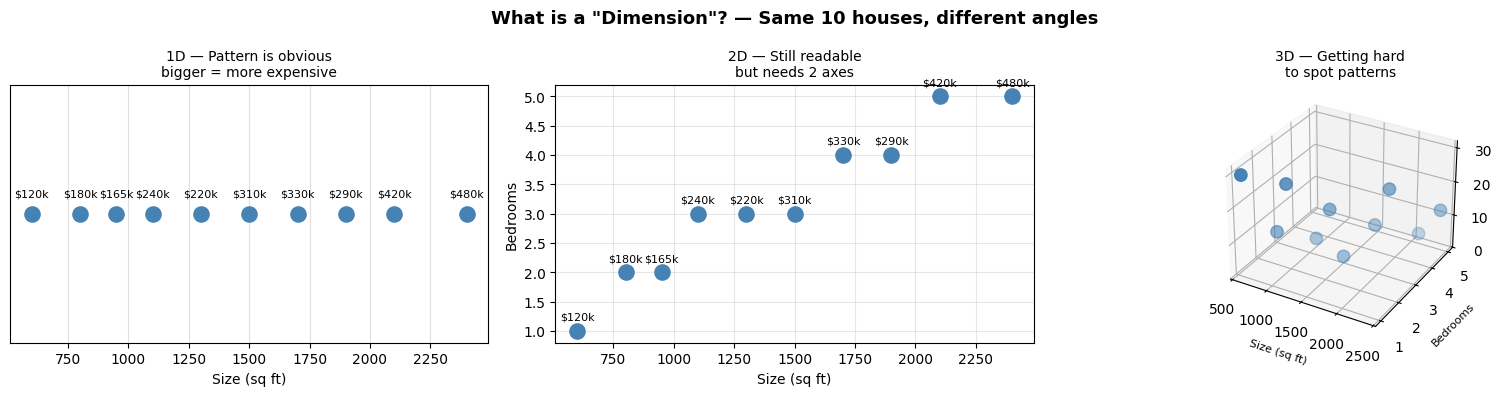

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D subplot

sizes    = houses['size_sqft'].values
bedrooms = houses['bedrooms'].values
ages     = houses['age_years'].values
prices   = houses['price_$1000'].values

figure = plt.figure(figsize=(16, 4))
figure.suptitle('What is a "Dimension"? — Same 10 houses, different angles',
                fontsize=13, fontweight='bold')

# ── Chart 1: 1D (size only) ──────────────────────────────────────────────────
ax1 = figure.add_subplot(1, 3, 1)
ax1.scatter(sizes, np.zeros(10), s=120, color='steelblue', zorder=3)
for i in range(10):
    ax1.annotate(f'${prices[i]}k', (sizes[i], 0),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=8)
ax1.set_xlabel('Size (sq ft)')
ax1.set_title('1D — Pattern is obvious\nbigger = more expensive', fontsize=10)
ax1.set_yticks([])
ax1.set_ylim(-0.5, 0.5)
ax1.grid(axis='x', alpha=0.4)

# ── Chart 2: 2D (size + bedrooms) ────────────────────────────────────────────
ax2 = figure.add_subplot(1, 3, 2)
ax2.scatter(sizes, bedrooms, s=120, color='steelblue', zorder=3)
for i in range(10):
    ax2.annotate(f'${prices[i]}k', (sizes[i], bedrooms[i]),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_xlabel('Size (sq ft)')
ax2.set_ylabel('Bedrooms')
ax2.set_title('2D — Still readable\nbut needs 2 axes', fontsize=10)
ax2.grid(alpha=0.3)

# ── Chart 3: 3D (size + bedrooms + age) ──────────────────────────────────────
ax3 = figure.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(sizes, bedrooms, ages, s=80, color='steelblue')
ax3.set_xlabel('Size (sq ft)', fontsize=8)
ax3.set_ylabel('Bedrooms', fontsize=8)
ax3.set_zlabel('Age (yrs)', fontsize=8)
ax3.set_title('3D — Getting hard\nto spot patterns', fontsize=10)

plt.tight_layout()
plt.show()


###  What we just saw

| Dimensions | What you notice |
|-----------|----------------|
| **1D** | Instantly clear — bigger = pricier |
| **2D** | Still readable, prices trend upward |
| **3D** | Already hard — age adds complexity |

> **Key takeaway:** Each new feature adds a dimension, and every new dimension makes the space harder to navigate — both for humans *and* for models.

---


##  Step 4 — The Curse in Action: Space Explodes, Data Doesn't

Here's the core problem, shown mathematically.

Imagine dividing each feature into **10 equal bins** (small buckets).  
How much of that grid does our data actually cover?

```
1 feature  →  10 boxes   →  10 houses fill  100%
2 features →  100 boxes  →  10 houses fill   10%
3 features →  1,000 boxes→  10 houses fill    1%
```

The number of boxes grows **exponentially** (10^dimensions).  
Your data stays the same size.  
Result: your model is mostly looking at **empty space**.


In [6]:
n_points = 10   # our 10 houses
bins     = 10   # divide each feature into 10 bins

dims_list     = [1, 2, 3, 4, 5, 6]
coverage_list = []
boxes_list    = []

print(f"{'Dims':>5} | {'Total Boxes':>12} | {'Coverage':>12} | Visual")
print("-" * 55)
for d in dims_list:
    total_boxes = bins ** d
    coverage    = min(100, (n_points / total_boxes) * 100)
    coverage_list.append(coverage)
    boxes_list.append(total_boxes)
    bar   = '█' * max(1, int(coverage / 5))
    label = f'{coverage:.4f}%' if coverage < 0.1 else f'{coverage:.2f}%'
    print(f"{d:>5} | {total_boxes:>12,} | {label:>12} | {bar}")


 Dims |  Total Boxes |     Coverage | Visual
-------------------------------------------------------
    1 |           10 |      100.00% | ████████████████████
    2 |          100 |       10.00% | ██
    3 |        1,000 |        1.00% | █
    4 |       10,000 |        0.10% | █
    5 |      100,000 |      0.0100% | █
    6 |    1,000,000 |      0.0010% | █


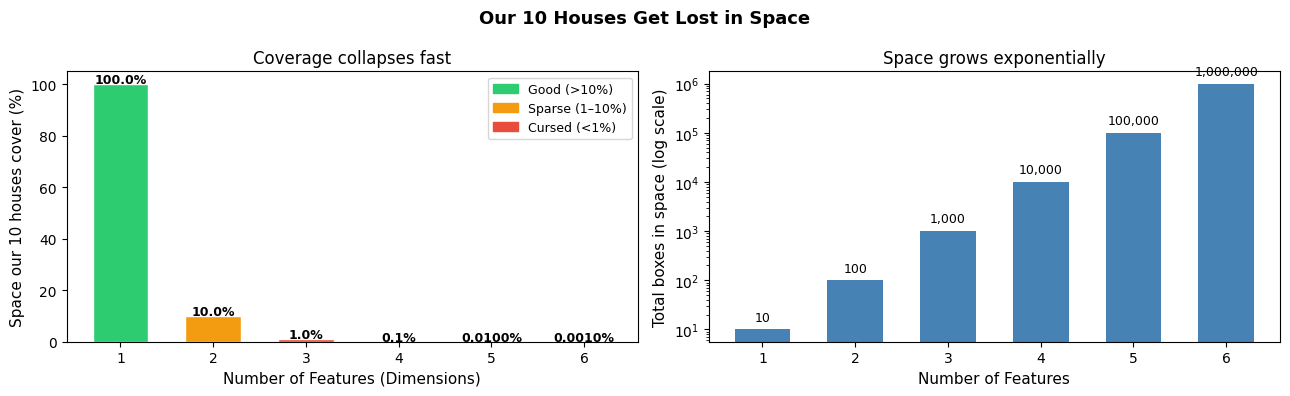

In [7]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Our 10 Houses Get Lost in Space', fontsize=13, fontweight='bold')

# ── Left: Coverage collapse ───────────────────────────────────────────────────
colors = ['#2ecc71' if c > 10 else '#f39c12' if c > 1 else '#e74c3c'
          for c in coverage_list]

axes[0].bar(dims_list, coverage_list, color=colors, width=0.6, edgecolor='white')
axes[0].set_xlabel('Number of Features (Dimensions)', fontsize=11)
axes[0].set_ylabel('Space our 10 houses cover (%)', fontsize=11)
axes[0].set_title('Coverage collapses fast')
for d, c in zip(dims_list, coverage_list):
    label = f'{c:.1f}%' if c >= 0.1 else f'{c:.4f}%'
    axes[0].text(d, c + 0.3, label, ha='center', fontsize=9, fontweight='bold')
axes[0].legend(handles=[
    Patch(color='#2ecc71', label='Good (>10%)'),
    Patch(color='#f39c12', label='Sparse (1–10%)'),
    Patch(color='#e74c3c', label='Cursed (<1%)'),
], fontsize=9)

# ── Right: Total boxes explosion ──────────────────────────────────────────────
axes[1].bar(dims_list, boxes_list, color='steelblue', width=0.6)
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Total boxes in space (log scale)', fontsize=11)
axes[1].set_title('Space grows exponentially')
for d, b in zip(dims_list, boxes_list):
    axes[1].text(d, b * 1.5, f'{b:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


###  What we just saw

- At **1 dimension**: 10 houses cover **100%** of space → the model has seen everything
- At **3 dimensions**: 10 houses cover only **1%** → the model is mostly guessing
- At **6 dimensions**: coverage is **0.001%** → the model is effectively blind

> **This is the Curse of Dimensionality.**  
> Adding features expands the space faster than your data can fill it.  
> In that empty space, the model has no examples to learn from — so predictions break down.

---


##  Step 5 — How the Curse Hurts Your Model's Predictions

Let's make this concrete. We'll simulate adding features one by one to our house price model and track the prediction error at each step.

**What we expect to see:**  
- First few useful features → error goes **down**
- After a point, adding more features → error goes **up**   

That turning point — where more features start hurting — is the curse in action.


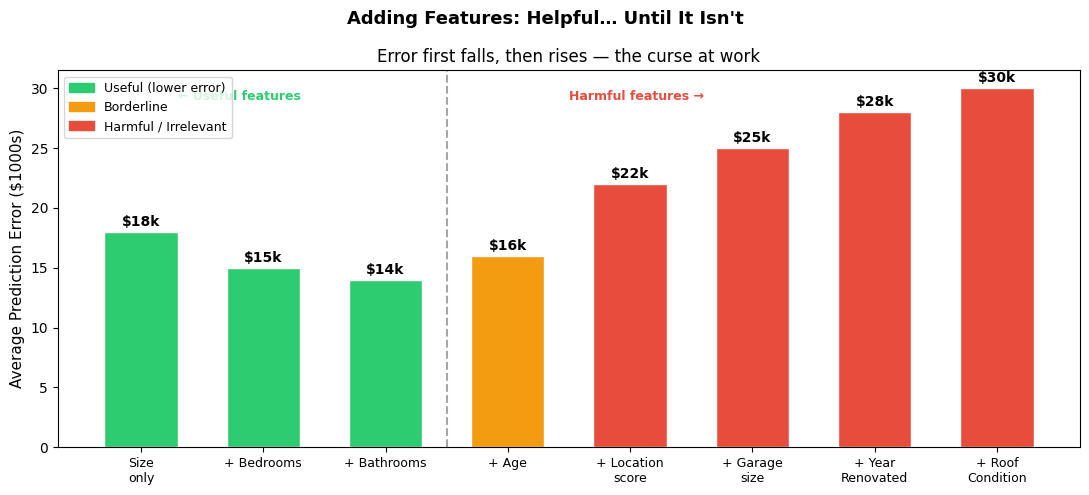

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Adding Features: Helpful… Until It Isn\'t', fontsize=13, fontweight='bold')

feature_names = [
    'Size\nonly',
    '+ Bedrooms',
    '+ Bathrooms',
    '+ Age',
    '+ Location\nscore',
    '+ Garage\nsize',
    '+ Year\nRenovated',
    '+ Roof\nCondition'
]
errors = [18, 15, 14, 16, 22, 25, 28, 30]  # prediction error in $1000s

colors = ['#2ecc71'] * 3 + ['#f39c12'] + ['#e74c3c'] * 4

bars = ax.bar(range(len(errors)), errors, color=colors, edgecolor='white', width=0.6)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, fontsize=9)
ax.set_ylabel('Average Prediction Error ($1000s)', fontsize=11)
ax.set_title('Error first falls, then rises — the curse at work')

# Value labels on bars
for i, (bar, err) in enumerate(zip(bars, errors)):
    ax.text(bar.get_x() + bar.get_width() / 2, err + 0.5,
            f'${err}k', ha='center', fontsize=10, fontweight='bold')

# Dividing line between useful vs. harmful features
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(0.3, 29, '← Useful features', color='#2ecc71', fontsize=9, fontweight='bold')
ax.text(3.5, 29, 'Harmful features →', color='#e74c3c', fontsize=9, fontweight='bold')

ax.legend(handles=[
    Patch(color='#2ecc71', label='Useful (lower error)'),
    Patch(color='#f39c12', label='Borderline'),
    Patch(color='#e74c3c', label='Harmful / Irrelevant'),
], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()


###  What we just saw

The sweet spot here is **3 features** (size + bedrooms + bathrooms) with a $14k error.

After that, every new feature makes the model worse — not because the features are lying, but because our 10-house dataset can't fill the expanding space.

> **Rule of thumb:** For every new feature you add, you roughly need **10× more data** to maintain the same model quality.

---


###  What to do with this

- **size_sqft vs bedrooms: ~0.99** — almost perfectly correlated. These two features are nearly duplicates. Keeping both is wasteful.  
- **age_years** — low correlation with the others. It adds genuinely independent information.

> **Action:** When two features are highly correlated (above ~0.9), consider dropping one — or using PCA to merge them (see next step).

---


##  Step 7 —  PCA — Compress Dimensions Without Losing Information

**Principal Component Analysis (PCA)** is a smarter solution.  
Instead of dropping features, it *combines* them into new "super-features" (called components) that capture the most important patterns.

**Analogy:** Imagine summarizing a 500-page book into 3 key paragraphs. You lose a little detail, but you get something far more useful and compact.

We'll apply PCA to `size_sqft` and `bedrooms` — our two nearly-duplicate features — and show that **1 component captures ~99% of their combined information**.


In [12]:
from sklearn.decomposition import PCA

# Step 1: Isolate the two correlated features
X_two = houses[['size_sqft', 'bedrooms']].values.astype(float)

# Step 2: Standardize (PCA is sensitive to scale — always do this first!)
X_scaled = (X_two - X_two.mean(axis=0)) / X_two.std(axis=0)

# Step 3: Fit PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

# Step 4: Print how much information each component captures
print("How much information does each component capture?")
print()
for i, var in enumerate(pca.explained_variance_ratio_):
    bar = '█' * int(var * 40)
    print(f"  Component {i+1}: {var*100:.1f}%  {bar}")

print()
print(f"→ Component 1 alone captures {pca.explained_variance_ratio_[0]*100:.1f}% of the info!")
print(f"  We can replace 2 features with 1 component, losing almost nothing.")


How much information does each component capture?

  Component 1: 98.5%  ███████████████████████████████████████
  Component 2: 1.5%  

→ Component 1 alone captures 98.5% of the info!
  We can replace 2 features with 1 component, losing almost nothing.


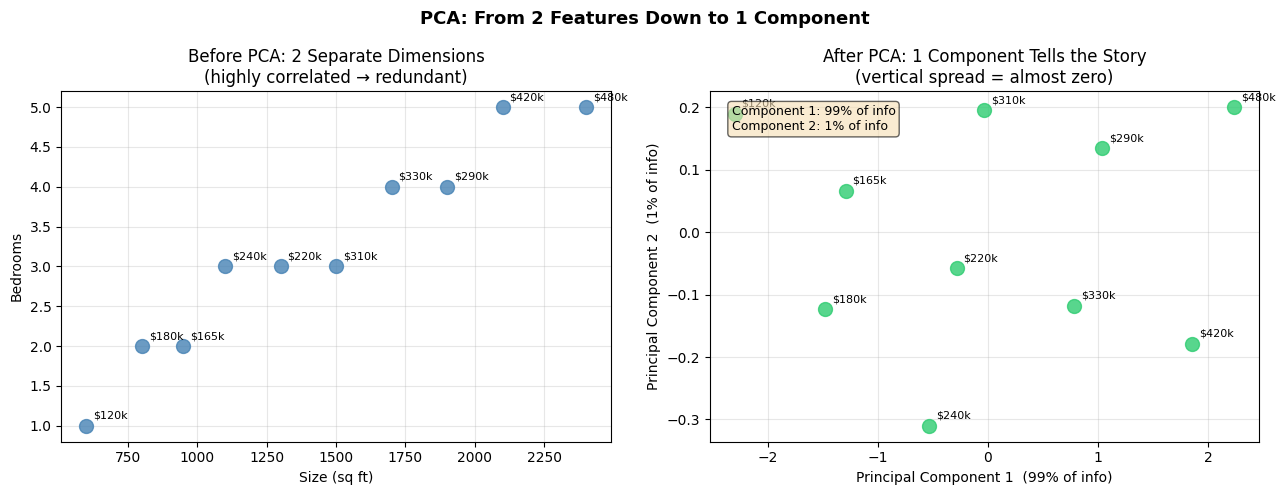

In [13]:
# Visualize: original 2D space vs. compressed PCA space
components = pca.transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA: From 2 Features Down to 1 Component', fontsize=13, fontweight='bold')

# ── Left: original features ───────────────────────────────────────────────────
ax1.scatter(houses['size_sqft'], houses['bedrooms'],
            s=100, color='steelblue', alpha=0.8, zorder=3)
for i, price in enumerate(houses['price_$1000']):
    ax1.annotate(f'${price}k',
                 (houses['size_sqft'].iloc[i], houses['bedrooms'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax1.set_xlabel('Size (sq ft)')
ax1.set_ylabel('Bedrooms')
ax1.set_title('Before PCA: 2 Separate Dimensions\n(highly correlated → redundant)')
ax1.grid(alpha=0.3)

# ── Right: PCA components ─────────────────────────────────────────────────────
ax2.scatter(components[:, 0], components[:, 1],
            s=100, color='#2ecc71', alpha=0.8, zorder=3)
for i, price in enumerate(houses['price_$1000']):
    ax2.annotate(f'${price}k',
                 (components[i, 0], components[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Principal Component 1  (99% of info)')
ax2.set_ylabel('Principal Component 2  (1% of info)')
ax2.set_title('After PCA: 1 Component Tells the Story\n(vertical spread = almost zero)')
ax2.grid(alpha=0.3)

# Annotation box
ax2.text(0.04, 0.96,
         f"Component 1: {pca.explained_variance_ratio_[0]*100:.0f}% of info\n"
         f"Component 2: {pca.explained_variance_ratio_[1]*100:.0f}% of info",
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()


###  What we just saw

- **Left chart:** Two dimensions, but the data forms a near-perfect diagonal line — clear redundancy.
- **Right chart:** PCA rotates the data so Component 1 captures all the meaningful spread. Component 2 is nearly flat — it adds almost nothing.

> **Result:** We compressed 2 features into 1 component and kept **99% of the information**. Our model now works in a lower-dimensional space, which means less empty space and better generalization.

---


##  Step 8 — Summary: What We Learned

| Step | What we did | Key takeaway |
|------|-------------|-------------|
| 1–2 | Built the dataset | 10 houses × 3 features |
| 3   | Visualized dimensions 1D → 3D | Each feature = one new axis |
| 4   | Measured space coverage | Space grows as 10^N — data can't keep up |
| 5   | Tracked prediction error | More features → worse model after a point |
| 6   | Checked correlations | Redundant features waste dimensions |
| 7   | Applied PCA | 2 features → 1 component, 99% info kept |

### The One Rule to Remember
> **More features ≠ better model.**  
> The best models use the *right* features — not the most features.

### What to Try Next
- Apply this to a real dataset (try the Boston Housing or California Housing dataset)
- Experiment with `n_components` in PCA — how few components can you keep while still predicting well?
- Try `SelectKBest` from sklearn for automated feature selection
